In [13]:
import pandas as pd

import requests
import time
import urllib.parse
import pandas as pd
from collections import defaultdict

BASE_URL = "https://rest.kegg.jp"


### KEGG helper

In [14]:
def kegg_get(path):
    """Simple helper with basic error handling + politeness delay."""
    url = f"{BASE_URL}/{path}"
    r = requests.get(url)
    if not r.ok:
        print(f"KEGG request failed for {path} (status {r.status_code})")
        return ""
    time.sleep(0.5)  # be polite to KEGG servers
    return r.text

### Map species name → KEGG organism code (automatic first hit)

In [17]:
def find_kegg_organism_code(name):
    """
    Use KEGG 'find genome' API to get organism code.
    Returns (org_code, description) or (None, None) if not found.
    """
    q = urllib.parse.quote(name)
    txt = kegg_get(f"find/genome/{q}")
    if not txt.strip():
        return None, None
    
    # Each line: 'genome:code\tDescription'
    first_line = txt.splitlines()[0]
    code_part, desc = first_line.split("\t", 1)
    org_code = code_part.split(":", 1)[1]  # remove 'genome:'
    return org_code, desc


In [16]:
df_sig = pd.read_csv('../data/pTau versus bacteria FDR 0.05.csv')
species_list = df_sig['bateria'].tolist()

In [18]:
rows = []
for sp in species_list:
    code, desc = find_kegg_organism_code(sp)
    rows.append({"query": sp, "kegg_org_code": code, "description": desc})

org_map_df = pd.DataFrame(rows)
org_map_df

,query,kegg_org_code,description
0,Aliivibrio salmonicida,T00782,vsa; Aliivibrio salmonicida LFI1238
1,Burkholderiales bacterium,T03654,bbag; Burkholderiales bacterium GJ-E10
2,Citromicrobium sp. JL47,T04089,cij; Citromicrobium sp. JL477
3,Mucilaginibacter gotj,T05131,mgot; Mucilaginibacter gotjawali SA3-7
4,Methylobacterium sp. DM,T05461,metd; Methylobacterium sp. DM1
...,...,...,...
543,Methylomicrobium buryense,None,None
544,Olsenella sp. GAM18,None,None
545,Hylemonella gracilis,T09883,hgr; Hylemonella gracilis NS1
546,Flavobacterium johnsoniae,T00508,fjo; Flavobacterium johnsoniae UW101


In [33]:
org_map_df.to_csv("../results/species_to_kegg_org_candidates.csv", index=False)


### For each KEGG organism code, fetch its KEGG pathways

In [26]:
def get_org_pathways(org_code):
    """
    Returns list of (pathway_id, pathway_name) for a KEGG organism code.
    Example pathway_id: 'path:eco00010'
    """
    txt = kegg_get(f"list/pathway/{org_code}")
    paths = []
    for line in txt.splitlines():
        if not line.strip():
            continue
        pid, pname = line.split("\t", 1)
        # Handle cases where pid may or may not have 'path:' prefix
        if ":" in pid:
            pid = pid.split(":", 1)[1]  # keep only 'eco00010'
        paths.append((pid, pname))
    return paths


In [27]:
# Build species × pathways matrix
species_to_paths = {}
all_paths = set()

for _, row in org_map_df.dropna(subset=["kegg_org_code"]).iterrows():
    sp = row["query"]
    org_code = row["kegg_org_code"]
    paths = get_org_pathways(org_code)
    species_to_paths[sp] = [p[0] for p in paths]
    all_paths.update(p[0] for p in paths)

len(species_to_paths), len(all_paths)


(322, 39410)

### Build a species × pathway presence/absence table

In [29]:
path_list = sorted(all_paths)
species = sorted(species_to_paths.keys())

# presence/absence matrix
data = []
for sp in species:
    sp_paths = set(species_to_paths[sp])
    row = [1 if pid in sp_paths else 0 for pid in path_list]
    data.append(row)

presence_df = pd.DataFrame(data, index=species, columns=path_list)
presence_df


,aaco00010,aaco00020,aaco00030,aaco00040,aaco00051,aaco00052,aaco00053,aaco00061,aaco00071,aaco00074,...,yti03420,yti03430,yti03440,yti03450,yti04122,yti04142,yti04146,yti04148,yti04980,yti04981
Achromobacter denitrificans,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acidaminococcus intestini,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acinetobacter defluvi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acinetobacter larvae,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acinetobacter sp. LOGEW,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xanthomonas albilineans,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Xanthomonas arboricola,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Xanthomonas oryzae,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Yersinia pestis,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
presence_df.to_csv("../results/species_by_kegg_pathway_presence.csv")


### Build a KEGG pathway ID → name table

In [32]:
path_to_name = {}

for sp, pids in species_to_paths.items():
    org_code = org_map_df.loc[org_map_df["query"] == sp, "kegg_org_code"].iloc[0]
    txt = kegg_get(f"list/pathway/{org_code}")
    for line in txt.splitlines():
        if not line.strip():
            continue
        pid_full, pname = line.split("\t", 1)
        # Handle cases where pid may or may not have 'path:' prefix
        if ":" in pid_full:
            pid = pid_full.split(":", 1)[1]
        else:
            pid = pid_full
        if pid not in path_to_name:
            path_to_name[pid] = pname

path_df = pd.DataFrame(
    [{"pathway_id": pid, "pathway_name": name} for pid, name in sorted(path_to_name.items())]
)
path_df.to_csv("../results/kegg_pathway_id_to_name.csv", index=False)
path_df


,pathway_id,pathway_name
0,aaco00010,Glycolysis / Gluconeogenesis - Alicyclobacillu...
1,aaco00020,Citrate cycle (TCA cycle) - Alicyclobacillus a...
2,aaco00030,Pentose phosphate pathway - Alicyclobacillus a...
3,aaco00040,Pentose and glucuronate interconversions - Ali...
4,aaco00051,Fructose and mannose metabolism - Alicyclobaci...
...,...,...
39405,yti04142,Lysosome - Paradevosia tibetensis
39406,yti04146,Peroxisome - Paradevosia tibetensis
39407,yti04148,Efferocytosis - Paradevosia tibetensis
39408,yti04980,Cobalamin transport and metabolism - Paradevos...


### Build a species–pathway edge list

In [ ]:
# 1. Load your data
# presence_df = pd.read_csv("species_by_kegg_pathway_presence.csv", index_col=0)
# path_df = pd.read_csv("kegg_pathway_id_to_name.csv")  # cols: pathway_id, pathway_name

# 2. (Optional) restrict to a smaller set of pathways for clarity
# Example A: TOP 20 most common pathways
pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
topN = 20
top_paths = pathway_counts.head(topN).index.tolist()

# Example B (instead or later): neuro-related pathways
neuro_ids = [
    "map00010","map00020","map00190",  # glycolysis, TCA, oxphos
    "map00061","map00564","map00100",  # lipid
    "map00780",                        # biotin
    "map01130"                         # antibiotic biosynthesis
]
# uncomment to use neuro set instead of topN:
# top_paths = [p for p in presence_df.columns if p in neuro_ids]

# 3. Filter matrix to selected pathways
sub = presence_df.loc[:, presence_df.columns.isin(top_paths)]

# 4. Merge pathway IDs → names
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# 5. Build edge list: one row per (species, pathway) where presence = 1
edges = []
for species, row in sub.iterrows():
    for pid, val in row.items():
        if val == 1:
            edges.append({
                "Species": species,
                "Pathway_ID": pid,
                "Pathway_Name": id_to_name.get(pid, pid)
            })

edges_df = pd.DataFrame(edges)
edges_df.to_csv("species_pathway_network_edges.csv", index=False)
edges_df.head()


### Python network figure

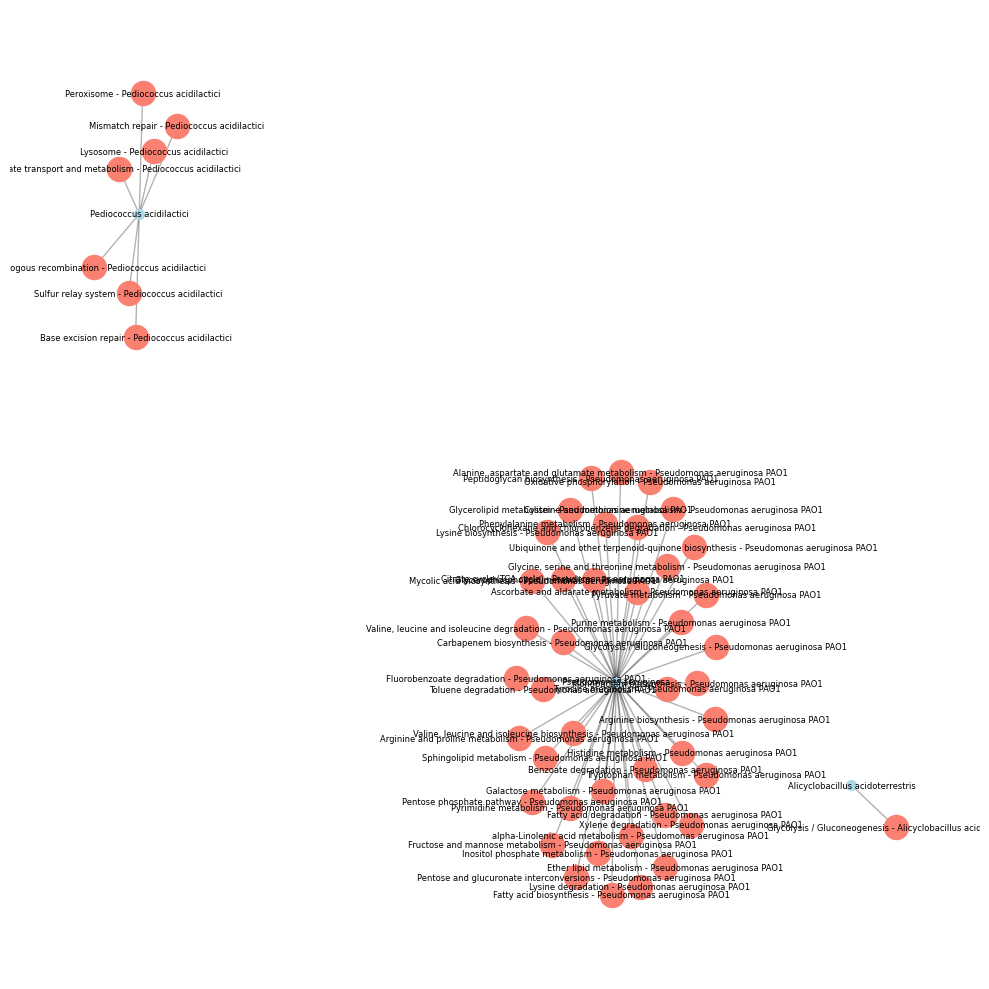

In [56]:
import networkx as nx
import matplotlib.pyplot as plt

# use a smaller subset for plotting
topN = 50
pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))
top_paths_small = pathway_counts.head(topN).index.tolist()
sub_small = presence_df.loc[:, presence_df.columns.isin(top_paths_small)]

G = nx.Graph()

# add nodes (same as before)
for species in sub_small.index:
    G.add_node(species, bipartite="species")
for pid in sub_small.columns:
    G.add_node(id_to_name.get(pid, pid), bipartite="pathway")

# add edges
for species, row in sub_small.iterrows():
    for pid, val in row.items():
        if val == 1:
            pname = id_to_name.get(pid, pid)
            G.add_edge(species, pname)

# 🔑 NEW: remove all nodes that have no edges
G.remove_nodes_from(list(nx.isolates(G)))

# layout and plotting
pos = nx.spring_layout(G, k=0.4, iterations=100)

plt.figure(figsize=(10, 10))
species_nodes  = [n for n, d in G.nodes(data=True) if d["bipartite"] == "species"]
pathway_nodes  = [n for n, d in G.nodes(data=True) if d["bipartite"] == "pathway"]

nx.draw_networkx_nodes(G, pos, nodelist=species_nodes, node_color="lightblue", node_size=50)
nx.draw_networkx_nodes(G, pos, nodelist=pathway_nodes, node_color="salmon", node_size=300)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=6)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_top10_pathways_connected_only.png", dpi=300)
plt.show()


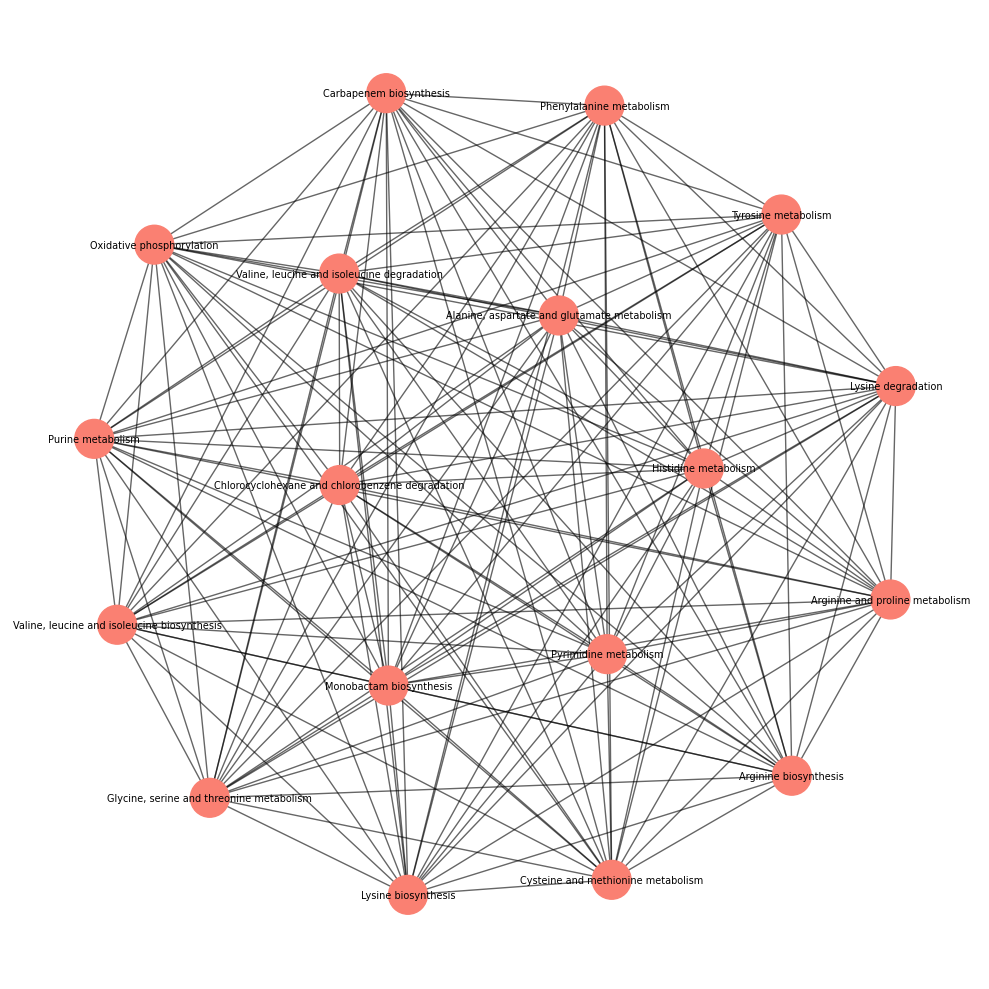

In [77]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ----- SETTINGS -----
topN = 20       # number of most common pathways to include
min_shared = 1  # minimum # shared species for an edge

# ----- 1. pick subset of pathways (topN most common) -----
pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
path_ids = pathway_counts.head(topN).index.tolist()
sub = presence_df.loc[:, presence_df.columns.isin(path_ids)]

# map pathway id -> readable name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# ----- 2. compute co-occurrence (shared species) between pathways -----
# co_mat[i,j] = # of species that have both pathway i and j
co_mat = sub.T.dot(sub)      # DataFrame: path × path

# ----- 3. build pathway–pathway network -----
G = nx.Graph()
for pid in path_ids:
    G.add_node(pid, label=id_to_name.get(pid, pid))

for i in path_ids:
    for j in path_ids:
        if j <= i:
            continue
        w = co_mat.loc[i, j]
        if w >= min_shared:
            G.add_edge(i, j, weight=int(w))

# remove isolated pathways (no shared species with others)
G.remove_nodes_from(list(nx.isolates(G)))

# ----- 4. plot network -----
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.5, iterations=200)

degrees = dict(G.degree())
node_sizes = [100 + 40 * degrees[n] for n in G.nodes()]
edge_widths = [d["weight"] for _, _, d in G.edges(data=True)]

nx.draw_networkx_nodes(G, pos, node_color="salmon", node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

# shorter labels: strip after " - " if present
labels = {n: id_to_name.get(n, n).split(" - ")[0] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

plt.axis("off")
plt.tight_layout()
plt.savefig("kegg_pathway_cooccurrence_network.png", dpi=300)
plt.show()


Network has 18 pathways and 153 edges


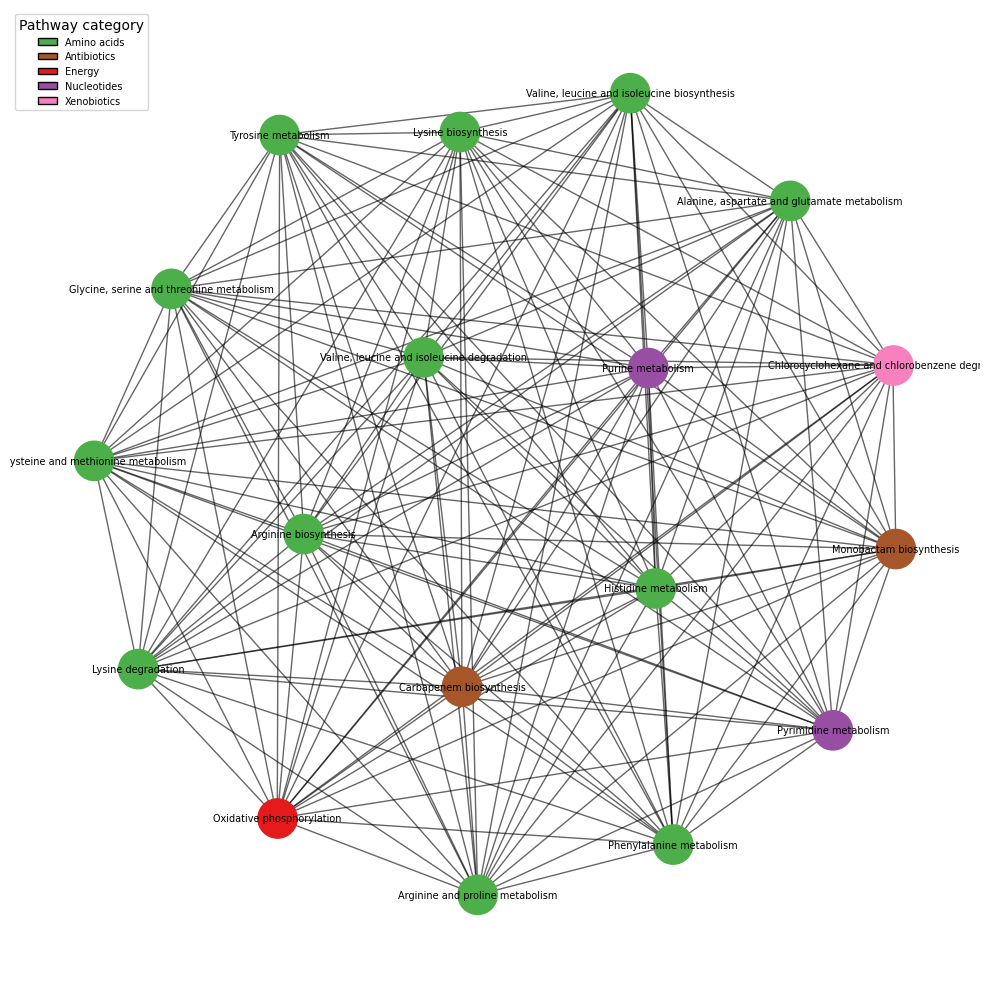

In [79]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----- SETTINGS -----
topN = 20       # number of most common pathways to include
min_shared = 1  # minimum # shared species for an edge

# ----- 1. pick subset of pathways (topN most common) -----
pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
path_ids = pathway_counts.head(topN).index.tolist()
sub = presence_df.loc[:, presence_df.columns.isin(path_ids)]

# map pathway id -> readable name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# ----- 1b. automatic category classifier from pathway name -----
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def classify_pathway(name: str) -> str:
    n = name.lower()
    # Energy metabolism
    if "oxidative phosphorylation" in n or "carbon fixation" in n or "photosynthesis" in n:
        return "Energy"
    # Carbohydrate metabolism
    if any(w in n for w in ["glycolysis", "gluconeogenesis", "pentose phosphate",
                            "citrate cycle", "tca cycle", "pyruvate metabolism",
                            "starch and sucrose", "fructose and mannose",
                            "galactose metabolism"]):
        return "Carbohydrate"
    # Amino acid metabolism / biosynthesis
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acids"
    # Nucleotide metabolism
    if "purine metabolism" in n or "pyrimidine metabolism" in n:
        return "Nucleotides"
    # Cofactors & vitamins (biotin etc.)
    if "biotin" in n or "folate" in n or "riboflavin" in n or "thiamine" in n:
        return "Cofactors/Vitamins"
    # Antibiotic / secondary metabolite biosynthesis
    if ("antibiotic" in n or "beta-lactam" in n or "carbapenem" in n or
        "monobactam" in n or "cephalosporin" in n or "penicillin" in n or
        "streptomycin" in n or "vancomycin" in n):
        return "Antibiotics"
    # Xenobiotic degradation
    if any(w in n for w in ["chlorobenzene", "benzoate", "xenobiotic",
                            "toluene", "dioxin", "caprolactam"]):
        return "Xenobiotics"
    return "Other"

type_colors = {
    "Energy":            "#e41a1c",
    "Carbohydrate":      "#377eb8",
    "Amino acids":       "#4daf4a",
    "Nucleotides":       "#984ea3",
    "Cofactors/Vitamins":"#ff7f00",
    "Antibiotics":       "#a65628",
    "Xenobiotics":       "#f781bf",
    "Other":             "#999999",
}

# category lookup for selected pathways
path_type = {}
for pid in path_ids:
    name = id_to_name.get(pid, pid)
    path_type[pid] = classify_pathway(name)

# ----- 2. compute co-occurrence (shared species) between pathways -----
co_mat = sub.T.dot(sub)      # DataFrame: path × path

# ----- 3. build pathway–pathway network -----
G = nx.Graph()
for pid in path_ids:
    G.add_node(pid, label=id_to_name.get(pid, pid), ptype=path_type[pid])

for i in path_ids:
    for j in path_ids:
        if j <= i:
            continue
        w = co_mat.loc[i, j]
        if w >= min_shared:
            G.add_edge(i, j, weight=int(w))

# remove isolated pathways (no shared species with others)
G.remove_nodes_from(list(nx.isolates(G)))

print("Network has", G.number_of_nodes(), "pathways and", G.number_of_edges(), "edges")

if G.number_of_nodes() == 0:
    print("⚠ No edges with current topN/min_shared; try adjusting parameters.")
else:
    # ----- 4. plot network with colors + legend -----
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=200)

    degrees = dict(G.degree())
    node_size_dict = {n: 120 + 40 * degrees[n] for n in G.nodes()}
    edge_widths = [d["weight"] for _, _, d in G.edges(data=True)]

    # draw nodes by type, with matching sizes
    present_types = sorted({d["ptype"] for _, d in G.nodes(data=True)})
    for ptype in present_types:
        nodes_of_type = [n for n, d in G.nodes(data=True) if d["ptype"] == ptype]
        color = type_colors.get(ptype, "#999999")
        sizes = [node_size_dict[n] for n in nodes_of_type]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodes_of_type,
            node_color=color,
            node_size=sizes,
            node_shape="o",
            label=ptype,
        )

    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

    # shorter labels: strip after " - " if present
    labels = {n: id_to_name.get(n, n).split(" - ")[0] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    plt.axis("off")
    plt.tight_layout()

    # legend for pathway categories actually present
    handles = [Patch(facecolor=type_colors[t], edgecolor='k', label=t)
               for t in present_types]
    plt.legend(handles=handles, title="Pathway category",
               loc="upper left", fontsize=7, frameon=True)

    plt.savefig("kegg_pathway_cooccurrence_network_typed.png", dpi=300)
    plt.show()



presence_df shape: (322, 39410)
path_df shape: (39410, 2)
Non-zero pathways in presence_df: 39410
Using 20 pathways in the network.
Network has 18 pathway nodes and 153 edges


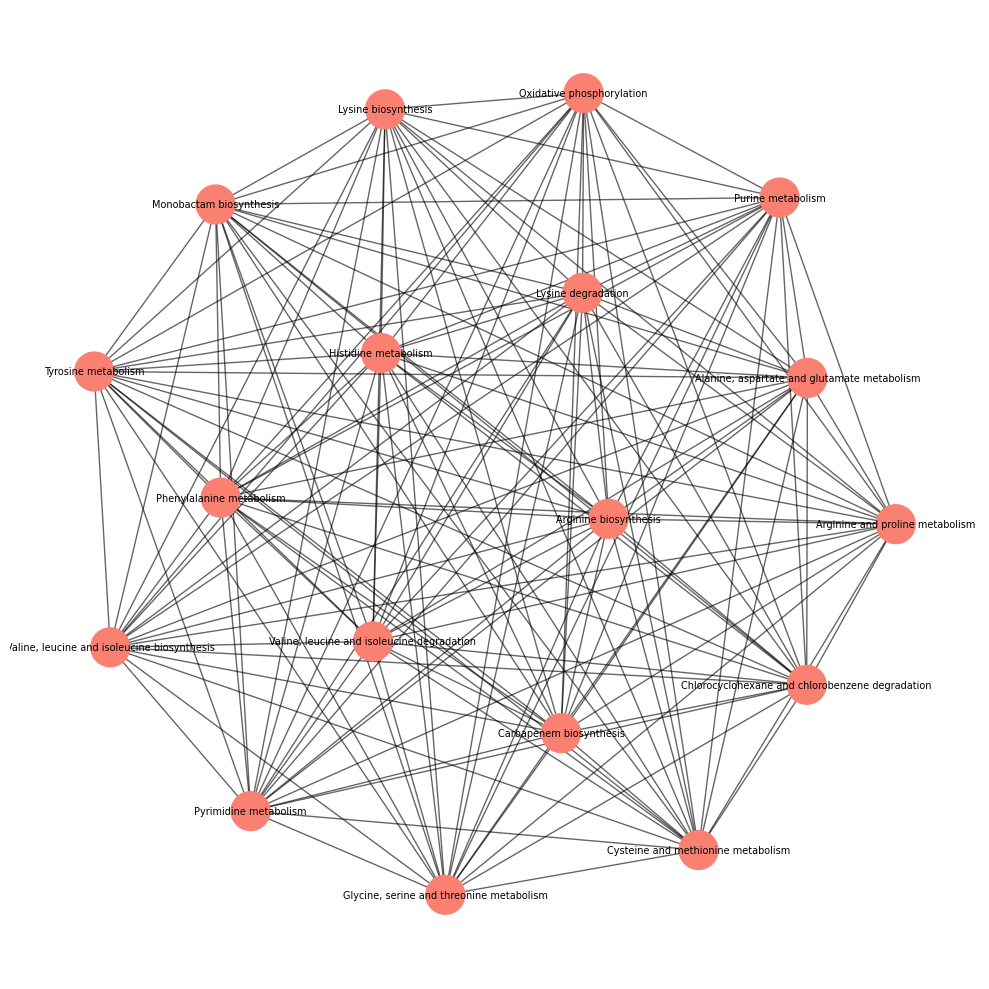

In [63]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ========================
# 0. basic sanity checks
# ========================
print("presence_df shape:", presence_df.shape)
print("path_df shape:", path_df.shape)

# make sure presence_df columns are pathway IDs present in path_df
valid_path_ids = set(path_df["pathway_id"])
presence_df = presence_df.loc[:, [c for c in presence_df.columns if c in valid_path_ids]]

# drop any pathways that have zero species
presence_df = presence_df.loc[:, presence_df.sum(axis=0) > 0]
print("Non-zero pathways in presence_df:", presence_df.shape[1])

# ========================
# 1. choose subset of pathways
# ========================
topN = 20        # number of most common pathways to include
min_shared = 1   # minimum # shared species to draw an edge

pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
path_ids = pathway_counts.head(topN).index.tolist()
sub = presence_df.loc[:, presence_df.columns.isin(path_ids)]

print("Using", len(path_ids), "pathways in the network.")

# map pathway id -> readable name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# ========================
# 2. compute co-occurrence (#shared species)
# ========================
# co_mat[i,j] = number of species that have both pathway i and j
co_mat = sub.T.dot(sub)  # path x path

# ========================
# 3. build pathway–pathway network
# ========================
G = nx.Graph()

# add pathway nodes
for pid in path_ids:
    G.add_node(pid, label=id_to_name.get(pid, pid))

# add edges where shared species >= min_shared
for i in path_ids:
    for j in path_ids:
        if j <= i:
            continue
        w = co_mat.loc[i, j]
        if w >= min_shared:
            G.add_edge(i, j, weight=int(w))

# remove isolated pathways (no shared species with any others)
G.remove_nodes_from(list(nx.isolates(G)))

print("Network has", G.number_of_nodes(), "pathway nodes and", G.number_of_edges(), "edges")

if G.number_of_nodes() == 0:
    print("⚠ No edges with current topN/min_shared; try increasing topN or lowering min_shared.")
else:
    # ========================
    # 4. plot network
    # ========================
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=200)

    degrees = dict(G.degree())
    node_sizes = [100 + 40 * degrees[n] for n in G.nodes()]
    edge_widths = [d["weight"] for _, _, d in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_color="salmon", node_size=node_sizes)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

    # shorten labels a bit
    labels = {n: id_to_name.get(n, n).split(" - ")[0] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig("kegg_pathway_cooccurrence_network.png", dpi=300)
    plt.show()


presence_df shape: (322, 39410)
path_df shape: (39410, 2)
Non-zero pathways in presence_df: 39410
Using 20 pathways in the network.
Network has 18 pathway nodes and 153 edges


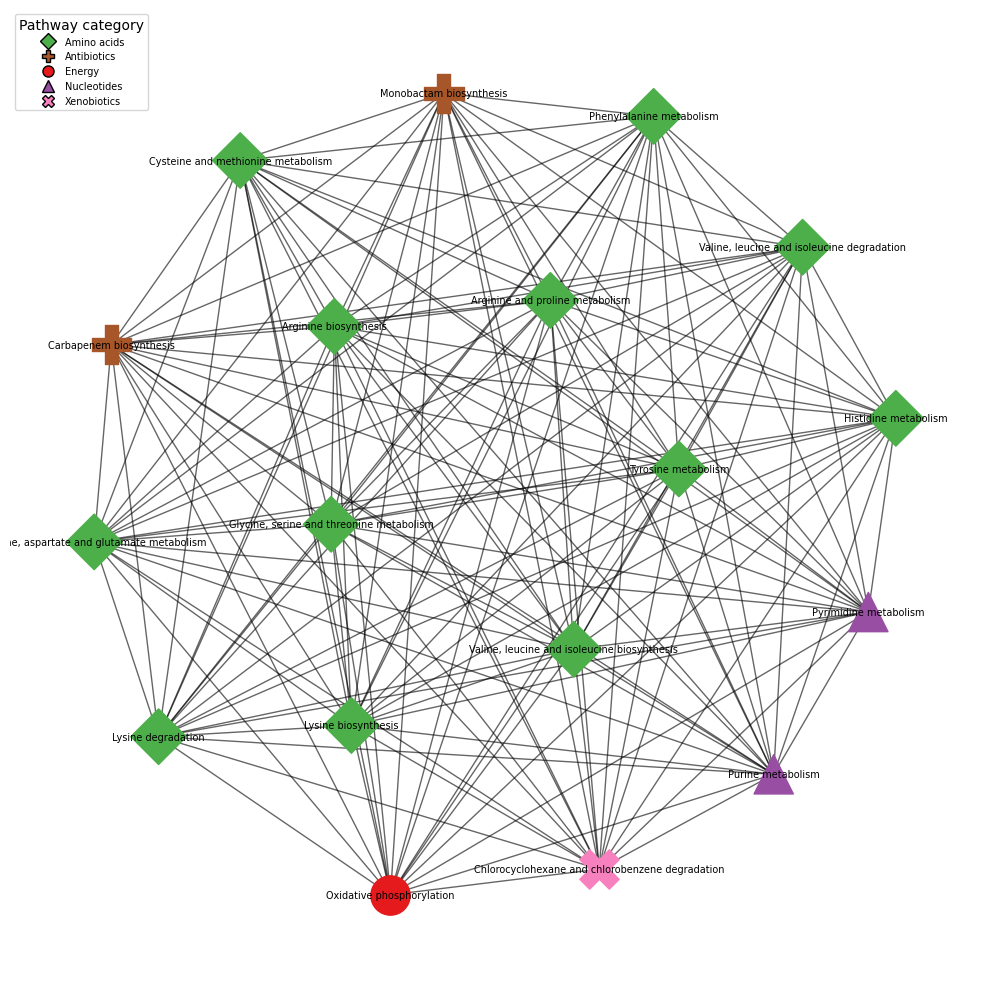

In [80]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ========================
# 0. basic sanity checks
# ========================
print("presence_df shape:", presence_df.shape)
print("path_df shape:", path_df.shape)

# make sure presence_df columns are pathway IDs present in path_df
valid_path_ids = set(path_df["pathway_id"])
presence_df = presence_df.loc[:, [c for c in presence_df.columns if c in valid_path_ids]]

# drop any pathways that have zero species
presence_df = presence_df.loc[:, presence_df.sum(axis=0) > 0]
print("Non-zero pathways in presence_df:", presence_df.shape[1])

# ========================
# 1. choose subset of pathways
# ========================
topN = 20        # number of most common pathways to include
min_shared = 1   # minimum # shared species to draw an edge

pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
path_ids = pathway_counts.head(topN).index.tolist()
sub = presence_df.loc[:, presence_df.columns.isin(path_ids)]

print("Using", len(path_ids), "pathways in the network.")

# map pathway id -> readable name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# ========================
# 1b. automatic pathway type classification
# ========================
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def classify_pathway(name: str) -> str:
    n = name.lower()
    # Energy metabolism
    if "oxidative phosphorylation" in n or "carbon fixation" in n or "photosynthesis" in n:
        return "Energy"
    # Carbohydrate metabolism
    if any(w in n for w in ["glycolysis", "gluconeogenesis", "pentose phosphate",
                            "citrate cycle", "tca cycle", "pyruvate metabolism",
                            "starch and sucrose", "fructose and mannose",
                            "galactose metabolism"]):
        return "Carbohydrate"
    # Amino acid metabolism / biosynthesis
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acids"
    # Nucleotide metabolism
    if "purine metabolism" in n or "pyrimidine metabolism" in n:
        return "Nucleotides"
    # Cofactors & vitamins (e.g. biotin)
    if any(w in n for w in ["biotin", "folate", "riboflavin", "thiamine", "vitamin"]):
        return "Cofactors/Vitamins"
    # Antibiotic / secondary metabolite biosynthesis
    if ("antibiotic" in n or "beta-lactam" in n or "carbapenem" in n or
        "monobactam" in n or "cephalosporin" in n or "penicillin" in n or
        "streptomycin" in n or "vancomycin" in n):
        return "Antibiotics"
    # Xenobiotic degradation
    if any(w in n for w in ["chlorobenzene", "benzoate", "xenobiotic",
                            "toluene", "dioxin", "caprolactam"]):
        return "Xenobiotics"
    return "Other"

type_colors = {
    "Energy":             "#e41a1c",
    "Carbohydrate":       "#377eb8",
    "Amino acids":        "#4daf4a",
    "Nucleotides":        "#984ea3",
    "Cofactors/Vitamins": "#ff7f00",
    "Antibiotics":        "#a65628",
    "Xenobiotics":        "#f781bf",
    "Other":              "#999999",
}

type_shapes = {
    "Energy":             "o",
    "Carbohydrate":       "s",
    "Amino acids":        "D",
    "Nucleotides":        "^",
    "Cofactors/Vitamins": "v",
    "Antibiotics":        "P",
    "Xenobiotics":        "X",
    "Other":              "o",
}

path_type = {}
for pid in path_ids:
    name = id_to_name.get(pid, pid)
    path_type[pid] = classify_pathway(name)

# ========================
# 2. compute co-occurrence (#shared species)
# ========================
co_mat = sub.T.dot(sub)  # path x path

# ========================
# 3. build pathway–pathway network
# ========================
G = nx.Graph()

# add pathway nodes with type attribute
for pid in path_ids:
    G.add_node(pid, label=id_to_name.get(pid, pid), ptype=path_type[pid])

# add edges where shared species >= min_shared
for i in path_ids:
    for j in path_ids:
        if j <= i:
            continue
        w = co_mat.loc[i, j]
        if w >= min_shared:
            G.add_edge(i, j, weight=int(w))

# remove isolated pathways (no shared species with others)
G.remove_nodes_from(list(nx.isolates(G)))

print("Network has", G.number_of_nodes(), "pathway nodes and", G.number_of_edges(), "edges")

if G.number_of_nodes() == 0:
    print("⚠ No edges with current topN/min_shared; try increasing topN or lowering min_shared.")
else:
    # ========================
    # 4. plot network with colors, shapes, legend
    # ========================
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=200)

    degrees = dict(G.degree())
    node_size_dict = {n: 120 + 40 * degrees[n] for n in G.nodes()}
    edge_widths = [d["weight"] for _, _, d in G.edges(data=True)]

    present_types = sorted({d["ptype"] for _, d in G.nodes(data=True)})

    # draw nodes grouped by type
    for ptype in present_types:
        nodes_of_type = [n for n, d in G.nodes(data=True) if d["ptype"] == ptype]
        color = type_colors.get(ptype, "#999999")
        shape = type_shapes.get(ptype, "o")
        sizes = [node_size_dict[n] for n in nodes_of_type]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodes_of_type,
            node_color=color,
            node_size=sizes,
            node_shape=shape,
            label=ptype
        )

    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

    # shorten labels a bit
    labels = {n: id_to_name.get(n, n).split(" - ")[0] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    plt.axis("off")
    plt.tight_layout()

    # legend with type, color, and marker shape
    legend_handles = []
    for ptype in present_types:
        color = type_colors.get(ptype, "#999999")
        shape = type_shapes.get(ptype, "o")
        legend_handles.append(
            Line2D([0], [0],
                   marker=shape, color='w',
                   markerfacecolor=color, markeredgecolor='k',
                   label=ptype, markersize=8)
        )

    plt.legend(handles=legend_handles, title="Pathway category",
               loc="upper left", fontsize=7, frameon=True)

    plt.savefig("kegg_pathway_cooccurrence_network_typed.png", dpi=300)
    plt.show()


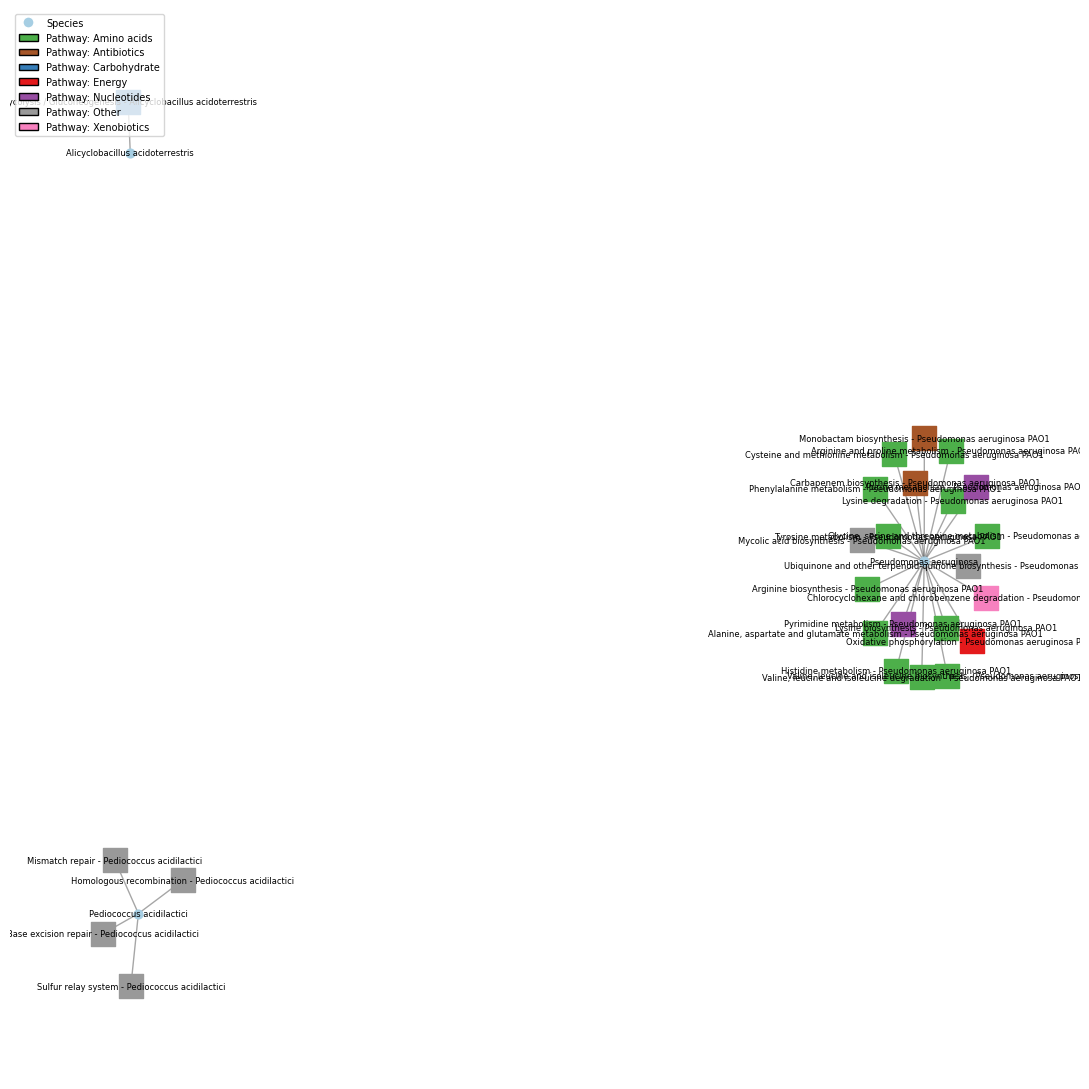

In [82]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ======================================================
# 0. choose pathways to display (top N most common)
# ======================================================
topN = 25
pathway_counts = presence_df.sum(axis=0).sort_values(ascending=False)
selected_path_ids = pathway_counts.head(topN).index.tolist()

sub = presence_df.loc[:, presence_df.columns.isin(selected_path_ids)]

# map id -> name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# ======================================================
# 1. automatic pathway type classifier (no user edits)
# ======================================================
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def classify_pathway(name: str) -> str:
    n = name.lower()
    # Energy metabolism
    if "oxidative phosphorylation" in n or "carbon fixation" in n or "photosynthesis" in n:
        return "Energy"
    # Carbohydrate metabolism
    if any(w in n for w in ["glycolysis", "gluconeogenesis", "pentose phosphate",
                            "citrate cycle", "tca cycle", "pyruvate metabolism",
                            "starch and sucrose", "fructose and mannose",
                            "galactose metabolism"]):
        return "Carbohydrate"
    # Amino acid metabolism / biosynthesis
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acids"
    # Nucleotide metabolism
    if "purine metabolism" in n or "pyrimidine metabolism" in n:
        return "Nucleotides"
    # Cofactors & vitamins (biotin etc.)
    if "biotin" in n or "folate" in n or "riboflavin" in n or "thiamine" in n:
        return "Cofactors/Vitamins"
    # Antibiotic / secondary metabolite biosynthesis
    if ("antibiotic" in n or "beta-lactam" in n or "carbapenem" in n or
        "monobactam" in n or "cephalosporin" in n or "penicillin" in n or
        "streptomycin" in n or "vancomycin" in n):
        return "Antibiotics"
    # Xenobiotic degradation
    if any(w in n for w in ["chlorobenzene", "benzoate", "xenobiotic",
                            "toluene", "dioxin", "caprolactam"]):
        return "Xenobiotics"
    return "Other"

type_colors = {
    "Energy":            "#e41a1c",
    "Carbohydrate":      "#377eb8",
    "Amino acids":       "#4daf4a",
    "Nucleotides":       "#984ea3",
    "Cofactors/Vitamins":"#ff7f00",
    "Antibiotics":       "#a65628",
    "Xenobiotics":       "#f781bf",
    "Other":             "#999999",
}

# ======================================================
# 2. build bipartite graph (species + pathways)
# ======================================================
B = nx.Graph()

# species nodes
for sp in sub.index:
    B.add_node(sp, bipartite="species")

# pathway nodes with automatic type
for pid in sub.columns:
    pname = id_to_name.get(pid, pid)
    ptype = classify_pathway(pname)
    B.add_node(pname, bipartite="pathway", pid=pid, ptype=ptype)

# edges species ↔ pathway
for sp, row in sub.iterrows():
    for pid, val in row.items():
        if val == 1:
            pname = id_to_name.get(pid, pid)
            B.add_edge(sp, pname)

# remove isolated nodes
B.remove_nodes_from(list(nx.isolates(B)))

# ======================================================
# 3. layout and plot (different shapes + legend)
# ======================================================
pos = nx.spring_layout(B, k=0.5, iterations=200)

species_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "species"]
pathway_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "pathway"]

plt.figure(figsize=(11, 11))

# species = light blue circles
nx.draw_networkx_nodes(
    B, pos,
    nodelist=species_nodes,
    node_color="#a6cee3",
    node_size=40,
    node_shape="o",
)

# pathways = squares colored by type
for ptype in sorted({d["ptype"] for n, d in B.nodes(data=True) if d.get("bipartite")=="pathway"}):
    nodes_of_type = [n for n, d in B.nodes(data=True)
                     if d.get("bipartite")=="pathway" and d.get("ptype")==ptype]
    color = type_colors.get(ptype, "#999999")
    nx.draw_networkx_nodes(
        B, pos,
        nodelist=nodes_of_type,
        node_color=color,
        node_size=300,
        node_shape="s",
        label=f"Pathway: {ptype}"
    )

nx.draw_networkx_edges(B, pos, alpha=0.35)
nx.draw_networkx_labels(B, pos, font_size=6)

plt.axis("off")

# legend: species + each pathway type actually present
species_handle = Line2D([0], [0], marker='o', color='w',
                        label='Species', markerfacecolor="#a6cee3",
                        markersize=8)
handles = [species_handle]
seen_types = sorted({d["ptype"] for n, d in B.nodes(data=True) if d.get("bipartite")=="pathway"})
for pt in seen_types:
    handles.append(
        Patch(facecolor=type_colors.get(pt, "#999999"),
              edgecolor='k',
              label=f"Pathway: {pt}")
    )

plt.legend(handles=handles, loc="upper left", fontsize=7, frameon=True)

plt.tight_layout()
plt.savefig("bipartite_species_pathways_typed_auto.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ======================================================
# 0. sanity + mapping id -> name
# ======================================================
print("presence_df shape:", presence_df.shape)
print("path_df shape:", path_df.shape)

id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# keep only pathway columns that we know names for
valid_ids = set(path_df["pathway_id"])
presence_df = presence_df.loc[:, [c for c in presence_df.columns if c in valid_ids]]

# drop pathways with zero species
presence_df = presence_df.loc[:, presence_df.sum(axis=0) > 0]
print("Non-zero pathways in presence_df:", presence_df.shape[1])

# ======================================================
# 1. automatic pathway type classifier (NO manual edits)
# ======================================================
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def classify_pathway(name: str) -> str:
    n = name.lower()
    # Energy metabolism
    if "oxidative phosphorylation" in n or "carbon fixation" in n or "photosynthesis" in n:
        return "Energy"
    # Carbohydrate metabolism
    if any(w in n for w in [
        "glycolysis", "gluconeogenesis", "pentose phosphate",
        "citrate cycle", "tca cycle", "pyruvate metabolism",
        "starch and sucrose", "fructose and mannose",
        "galactose metabolism"
    ]):
        return "Carbohydrate"
    # Amino acid metabolism / biosynthesis
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acids"
    # Nucleotide metabolism
    if "purine metabolism" in n or "pyrimidine metabolism" in n:
        return "Nucleotides"
    # Cofactors & vitamins (biotin etc.)
    if any(w in n for w in ["biotin", "folate", "riboflavin", "thiamine", "vitamin"]):
        return "Cofactors/Vitamins"
    # Antibiotic / secondary metabolite biosynthesis
    if any(w in n for w in ["antibiotic", "beta-lactam", "carbapenem",
                            "monobactam", "cephalosporin", "penicillin",
                            "streptomycin", "vancomycin"]):
        return "Antibiotics"
    # Xenobiotic degradation
    if any(w in n for w in ["chlorobenzene", "benzoate", "xenobiotic",
                            "toluene", "dioxin", "caprolactam"]):
        return "Xenobiotics"
    return "Other"

type_colors = {
    "Energy":             "#e41a1c",
    "Carbohydrate":       "#377eb8",
    "Amino acids":        "#4daf4a",
    "Nucleotides":        "#984ea3",
    "Cofactors/Vitamins": "#ff7f00",
    "Antibiotics":        "#a65628",
    "Xenobiotics":        "#f781bf",
    "Other":              "#999999",
}

# ======================================================
# 2. select METABOLIC pathways only
#    - KEGG names that contain "metabolism" OR
#    - classified into one of the metabolic categories above (not "Other")
#    then take topN by prevalence
# ======================================================
topN = 1000  # total number of metabolic pathways to visualize

meta_ids = []
meta_types = {}

for pid, name in id_to_name.items():
    if pid not in presence_df.columns:
        continue
    ptype = classify_pathway(name)
    if "metabolism" in name.lower() or ptype in {"Energy", "Carbohydrate", "Amino acids",
                                                 "Nucleotides", "Cofactors/Vitamins",
                                                 "Xenobiotics"}:
        meta_ids.append(pid)
        meta_types[pid] = ptype

# restrict presence_df to these metabolic pathways
meta_df = presence_df.loc[:, presence_df.columns.isin(meta_ids)]
# rank by how many species have each pathway
meta_counts = meta_df.sum(axis=0).sort_values(ascending=False)
selected_path_ids = meta_counts.head(topN).index.tolist()

print(f"Total metabolic pathways found: {len(meta_ids)}")
print(f"Using top {len(selected_path_ids)} metabolic pathways.")

# submatrix for selected metabolic pathways
sub = meta_df.loc[:, meta_df.columns.isin(selected_path_ids)]

# ======================================================
# 3. build bipartite graph (species + pathways)
# ======================================================
B = nx.Graph()

# add species nodes
for sp in sub.index:
    B.add_node(sp, bipartite="species")

# add pathway nodes with type
for pid in sub.columns:
    pname = id_to_name.get(pid, pid)
    ptype = meta_types.get(pid, "Other")
    B.add_node(pname, bipartite="pathway", pid=pid, ptype=ptype)

# edges species ↔ pathway (this is the "bridge" you mentioned)
for sp, row in sub.iterrows():
    for pid, val in row.items():
        if val == 1:
            pname = id_to_name.get(pid, pid)
            B.add_edge(sp, pname)

# remove isolated nodes
B.remove_nodes_from(list(nx.isolates(B)))

print("Bipartite graph has", B.number_of_nodes(), "nodes and", B.number_of_edges(), "edges")

# ======================================================
# 4. split into connected components and plot each separately
# ======================================================
components = list(nx.connected_components(B))
print("Number of connected components:", len(components))

comp_index = 0
for nodes in components:
    H = B.subgraph(nodes).copy()
    # skip tiny components (e.g., single node)
    if H.number_of_nodes() < 3:
        continue

    comp_index += 1
    pos = nx.spring_layout(H, k=0.5, iterations=200)

    species_nodes = [n for n, d in H.nodes(data=True) if d["bipartite"] == "species"]
    pathway_nodes = [n for n, d in H.nodes(data=True) if d["bipartite"] == "pathway"]

    plt.figure(figsize=(8, 8))

    # species = light blue circles
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=species_nodes,
        node_color="#0F6A38",
        node_size=60,
        node_shape="o",
    )

    # pathways = squares colored by type
    present_types = sorted({d["ptype"] for _, d in H.nodes(data=True) if d.get("bipartite")=="pathway"})
    for ptype in present_types:
        nodes_of_type = [n for n, d in H.nodes(data=True)
                         if d.get("bipartite")=="pathway" and d.get("ptype")==ptype]
        color = type_colors.get(ptype, "#999999")
        nx.draw_networkx_nodes(
            H, pos,
            nodelist=nodes_of_type,
            node_color=color,
            node_size=260,
            node_shape="s",
            label=f"{ptype}"
        )

    nx.draw_networkx_edges(H, pos, alpha=0.35)
    nx.draw_networkx_labels(H, pos, font_size=6)

    plt.axis("off")

    # legend: species + pathway types in THIS component
    species_handle = Line2D([0], [0], marker='o', color='w',
                            label='Species', markerfacecolor="#0F6A38",
                            markersize=10)
    handles = [species_handle]
    for pt in present_types:
        handles.append(
            Patch(facecolor=type_colors.get(pt, "#999999"),
                  edgecolor='k',
                  label=f"Pathway: {pt}")
        )

    plt.legend(handles=handles, loc="upper left", fontsize=7, frameon=True)

    plt.tight_layout()
    outname = f"../results/metabolomics_1000/bipartite_metabolic_component_{comp_index}.png"
    plt.savefig(outname, dpi=300)
    plt.show()
    print("Saved:", outname)


presence_df shape: (322, 39410)
path_df shape: (39410, 2)
Non-zero pathways in presence_df: 39410


In [86]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# 0. basic prep
# =========================
print("presence_df shape:", presence_df.shape)
print("path_df shape:", path_df.shape)

# id -> name
id_to_name = dict(zip(path_df["pathway_id"], path_df["pathway_name"]))

# keep only pathway columns that have known names
valid_ids = set(path_df["pathway_id"])
presence_df = presence_df.loc[:, [c for c in presence_df.columns if c in valid_ids]]

# drop pathways with zero species
presence_df = presence_df.loc[:, presence_df.sum(axis=0) > 0]
print("Non-zero pathways in presence_df:", presence_df.shape[1])

# =========================
# 1. classify metabolic pathways automatically
# =========================
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def classify_pathway(name: str) -> str:
    n = name.lower()
    # Energy metabolism
    if "oxidative phosphorylation" in n or "carbon fixation" in n or "photosynthesis" in n:
        return "Energy"
    # Carbohydrate metabolism
    if any(w in n for w in [
        "glycolysis", "gluconeogenesis", "pentose phosphate",
        "citrate cycle", "tca cycle", "pyruvate metabolism",
        "starch and sucrose", "fructose and mannose",
        "galactose metabolism"
    ]):
        return "Carbohydrate"
    # Amino acid metabolism / biosynthesis
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acids"
    # Nucleotide metabolism
    if "purine metabolism" in n or "pyrimidine metabolism" in n:
        return "Nucleotides"
    # Cofactors & vitamins (biotin etc.)
    if any(w in n for w in ["biotin", "folate", "riboflavin", "thiamine", "vitamin"]):
        return "Cofactors/Vitamins"
    # Xenobiotic degradation (optional metabolic)
    if any(w in n for w in ["chlorobenzene", "benzoate", "xenobiotic",
                            "toluene", "dioxin", "caprolactam"]):
        return "Xenobiotics"
    return "Other"

# find metabolic pathway IDs
metabolic_ids = []
for pid, name in id_to_name.items():
    if pid not in presence_df.columns:
        continue
    ptype = classify_pathway(name)
    if "metabolism" in name.lower() or ptype in {
        "Energy", "Carbohydrate", "Amino acids",
        "Nucleotides", "Cofactors/Vitamins", "Xenobiotics"
    }:
        metabolic_ids.append(pid)

print("Total metabolic pathway IDs:", len(metabolic_ids))

# restrict to metabolic pathways
met_df = presence_df.loc[:, presence_df.columns.isin(metabolic_ids)]

# optionally keep only topN metabolic pathways by prevalence
topN = 500
met_counts = met_df.sum(axis=0).sort_values(ascending=False)
selected_met_ids = met_counts.head(topN).index.tolist()
met_sub = met_df.loc[:, met_df.columns.isin(selected_met_ids)]

print("Using", len(selected_met_ids), "metabolic pathways for species network.")

# =========================
# 2. species–species co-occurrence via shared metabolic pathways
# =========================
# co_species[i,j] = number of shared metabolic pathways
co_species = met_sub.dot(met_sub.T)  # species x species

# build species graph
min_shared_paths = 1  # increase (e.g. 2,3) to keep only strong links
G = nx.Graph()
for sp in met_sub.index:
    G.add_node(sp)

for i in met_sub.index:
    for j in met_sub.index:
        if j <= i:
            continue
        w = co_species.loc[i, j]
        if w >= min_shared_paths:
            G.add_edge(i, j, weight=int(w))

# remove isolated species (no shared metabolic pathways)
G.remove_nodes_from(list(nx.isolates(G)))

print("Species network has", G.number_of_nodes(), "species and", G.number_of_edges(), "edges")

# =========================
# 3. plot species–species network (bridged by metabolic pathways)
# =========================
if G.number_of_nodes() == 0:
    print("⚠ No species connections with current settings; try lowering min_shared_paths.")
else:
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=200)

    degrees = dict(G.degree())
    node_sizes = [50 + 20 * degrees[n] for n in G.nodes()]
    edge_widths = [d["weight"] for _, _, d in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos,
                           node_color="#a6cee3",
                           node_size=node_sizes,
                           node_shape="o")
    nx.draw_networkx_edges(G, pos,
                           width=edge_widths,
                           alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=6)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig("species_network_shared_metabolic_pathways.png", dpi=300)
    plt.show()


presence_df shape: (322, 39410)
path_df shape: (39410, 2)
Non-zero pathways in presence_df: 39410
Total metabolic pathway IDs: 21127
Using 500 metabolic pathways for species network.
Total metabolic pathway IDs: 21127
Using 500 metabolic pathways for species network.
Species network has 0 species and 0 edges
⚠ No species connections with current settings; try lowering min_shared_paths.
Species network has 0 species and 0 edges
⚠ No species connections with current settings; try lowering min_shared_paths.


In [83]:
comp_index

1